<a href="https://colab.research.google.com/github/wsteve16/Intro-to-Machine-Learning/blob/main/ML_HW_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

final train loss = 0.4678, final train accuracy = 0.7704
final val loss   = 0.5105, final val accuracy   = 0.7532


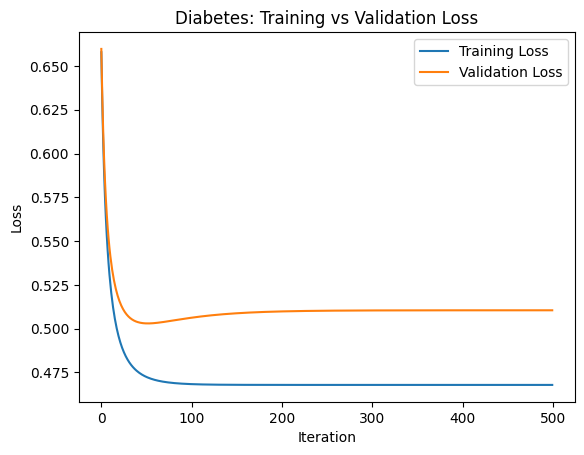

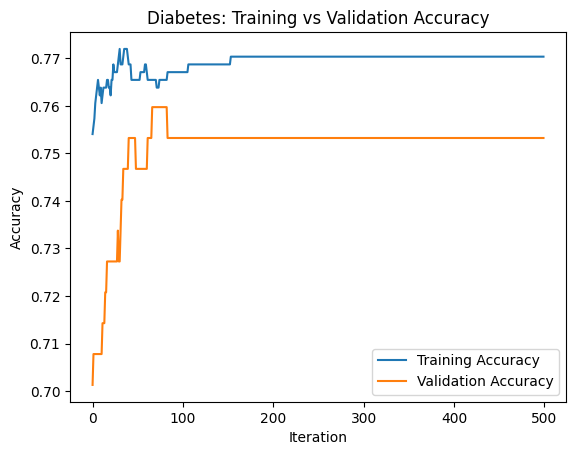

accuracy=0.7532
precision=0.6491
recall=0.6727
f1=0.6607


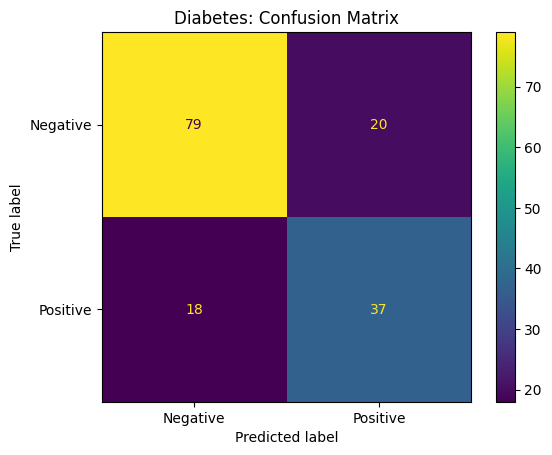

final train loss = 0.0599, final train accuracy = 0.9868
final val loss   = 0.0564, final val accuracy   = 0.9825


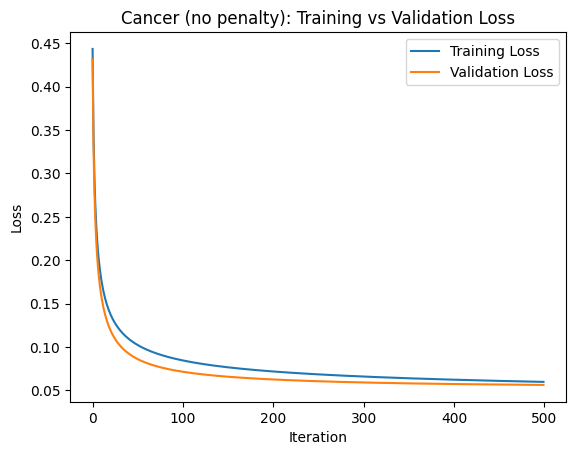

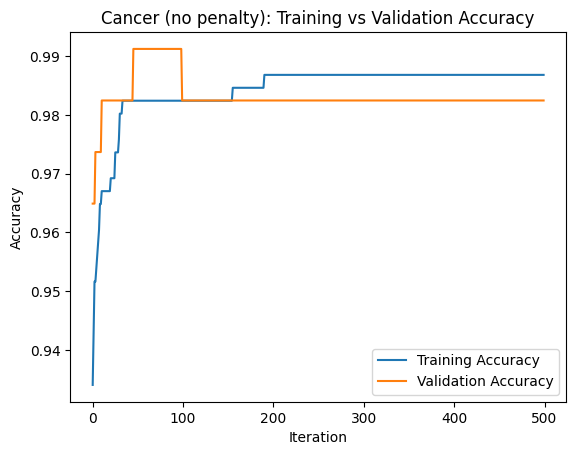

accuracy=0.9825
precision=0.9767
recall=0.9767
f1=0.9767


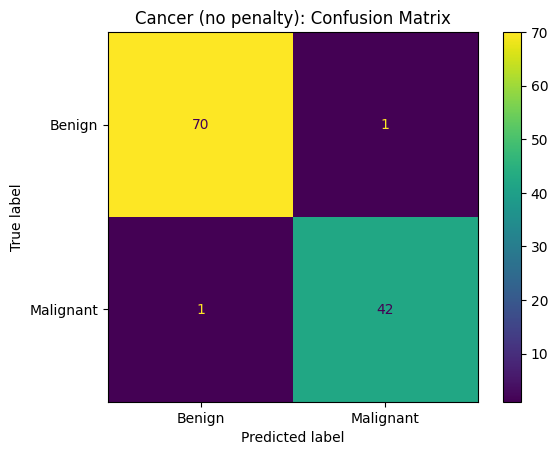

final train loss = 0.1390, final train accuracy = 0.9692
final val loss   = 0.1249, final val accuracy   = 0.9825


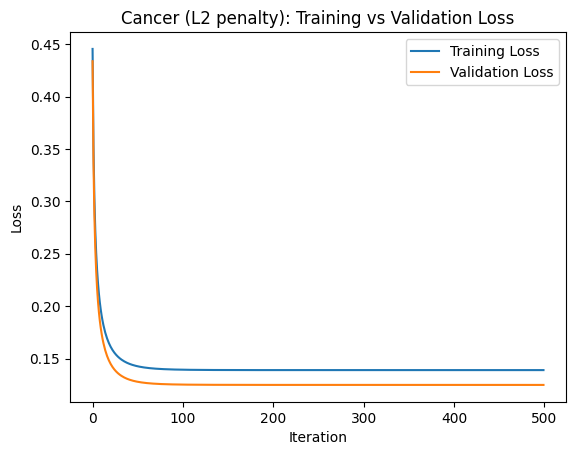

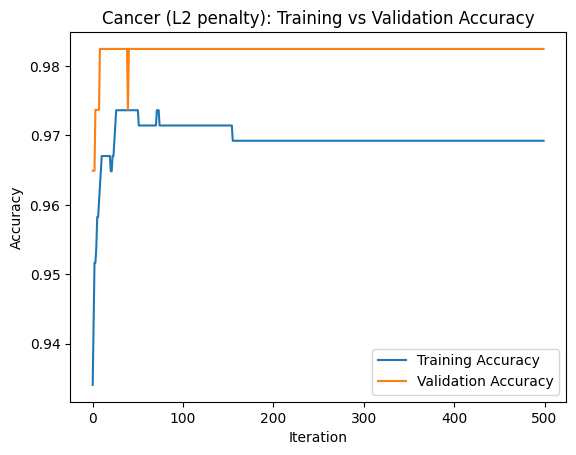

accuracy=0.9825
precision=1.0000
recall=0.9535
f1=0.9762


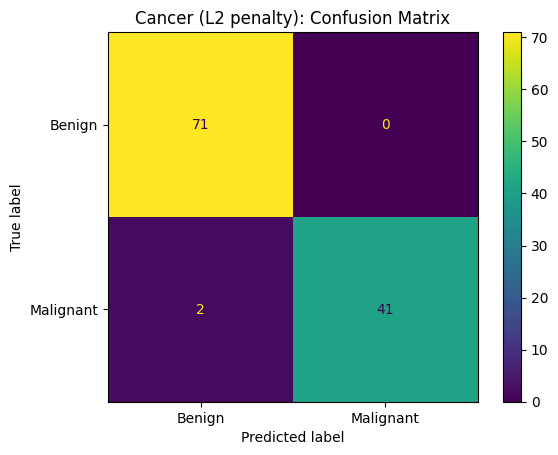

no-penalty coefficient norm: 3.302
L2-penalty coefficient norm: 1.104


In [5]:
#Intro to ML HW 3
#setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

diabetes_path = 'diabetes.csv'
diabetes_df = pd.read_csv(diabetes_path)

cancer_path  = 'Cancer.csv'
cancer_df= pd.read_csv(cancer_path)
#Q1 - Using the diabetes dataset, build a logistic regression binary classifier for positive diabetes.
#Please use 80% and 20% split between training and evaluation (test). Make sure to perform proper scaling and standardization
#before your training. Draw your training results, including loss and classification accuracy over iterations.
#Also, report your results, including accuracy, precision, and recall, FI score. At the end, plot the confusion matrix representing your binary classifier.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (accuracy_score, log_loss, precision_score,
                              recall_score, f1_score, ConfusionMatrixDisplay)

features = [c for c in diabetes_df.columns if c != 'Outcome']
X = diabetes_df[features].values.astype(float)
y = diabetes_df['Outcome'].values.astype(float)

#80/20 split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

#SGDClassifier with log loss = logistic regression trained with gradient
#descent. partial_fit() does one gradient step per call
n_iterations = 500
model = SGDClassifier(loss='log_loss', learning_rate='constant', eta0=0.0005, random_state=42)
classes = np.array([0, 1])

train_loss, val_loss, train_acc, val_acc = [], [], [], []
for i in range(n_iterations):
    model.partial_fit(X_train, y_train, classes=classes)
    train_loss.append(log_loss(y_train, model.predict_proba(X_train)[:, 1]))
    val_loss.append(log_loss(y_val, model.predict_proba(X_val)[:, 1]))
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    val_acc.append(accuracy_score(y_val, model.predict(X_val)))

print(f"final train loss = {train_loss[-1]:.4f}, final train accuracy = {train_acc[-1]:.4f}")
print(f"final val loss   = {val_loss[-1]:.4f}, final val accuracy   = {val_acc[-1]:.4f}")

plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Diabetes: Training vs Validation Loss')
plt.legend()
plt.show()

plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Diabetes: Training vs Validation Accuracy')
plt.legend()
plt.show()

val_pred = model.predict(X_val)
print(f"accuracy={accuracy_score(y_val, val_pred):.4f}")
print(f"precision={precision_score(y_val, val_pred):.4f}")
print(f"recall={recall_score(y_val, val_pred):.4f}")
print(f"f1={f1_score(y_val, val_pred):.4f}")

ConfusionMatrixDisplay.from_predictions(y_val, val_pred, display_labels=['Negative', 'Positive'])
plt.title('Diabetes: Confusion Matrix')
plt.show()


#Q2 -Use the cancer dataset to build a logistic regression model to classify the type of cancer (Malignant vs. benign).
# First, create a logistic regression that takes all 30 input features for classification. Please use 80% and 20% split between training and evaluation (test).
# Make sure to perform proper scaling and standardization before your training. Draw your training results, including loss and classification
#accuracy over iterations. Also, report your results, including accuracy, precision, recall and F1 score. At the end, plot the confusion
#matrix representing your binary classifier.

cancer_df = cancer_df.drop(columns=['id', 'Unnamed: 32'])
y_c = cancer_df['diagnosis'].map({'M': 1, 'B': 0}).values.astype(float)
X_c = cancer_df.drop(columns=['diagnosis']).values.astype(float)

#80/20 split
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

#standardize
scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_val_c = scaler_c.transform(X_val_c)

#no penalty
n_iterations = 500
model_c = SGDClassifier(loss='log_loss', penalty=None, learning_rate='constant', eta0=0.0005, random_state=42)
classes = np.array([0, 1])

train_loss_c, val_loss_c, train_acc_c, val_acc_c = [], [], [], []
for i in range(n_iterations):
    model_c.partial_fit(X_train_c, y_train_c, classes=classes)
    train_loss_c.append(log_loss(y_train_c, model_c.predict_proba(X_train_c)[:, 1]))
    val_loss_c.append(log_loss(y_val_c, model_c.predict_proba(X_val_c)[:, 1]))
    train_acc_c.append(accuracy_score(y_train_c, model_c.predict(X_train_c)))
    val_acc_c.append(accuracy_score(y_val_c, model_c.predict(X_val_c)))

print(f"final train loss = {train_loss_c[-1]:.4f}, final train accuracy = {train_acc_c[-1]:.4f}")
print(f"final val loss   = {val_loss_c[-1]:.4f}, final val accuracy   = {val_acc_c[-1]:.4f}")

plt.plot(train_loss_c, label='Training Loss')
plt.plot(val_loss_c, label='Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Cancer (no penalty): Training vs Validation Loss')
plt.legend()
plt.show()

plt.plot(train_acc_c, label='Training Accuracy')
plt.plot(val_acc_c, label='Validation Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Cancer (no penalty): Training vs Validation Accuracy')
plt.legend()
plt.show()

val_pred_c = model_c.predict(X_val_c)
print(f"accuracy={accuracy_score(y_val_c, val_pred_c):.4f}")
print(f"precision={precision_score(y_val_c, val_pred_c):.4f}")
print(f"recall={recall_score(y_val_c, val_pred_c):.4f}")
print(f"f1={f1_score(y_val_c, val_pred_c):.4f}")

ConfusionMatrixDisplay.from_predictions(y_val_c, val_pred_c, display_labels=['Benign', 'Malignant'])
plt.title('Cancer (no penalty): Confusion Matrix')
plt.show()


#How about adding a weight penalty here, considering the number of parameters. Add the weight penalty and repeat the training and report the results.

#try L2 penalty (weight decay)
model_c_reg = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.1,
                             learning_rate='constant', eta0=0.0005, random_state=42)

train_loss_reg, val_loss_reg, train_acc_reg, val_acc_reg = [], [], [], []
for i in range(n_iterations):
    model_c_reg.partial_fit(X_train_c, y_train_c, classes=classes)
    train_loss_reg.append(log_loss(y_train_c, model_c_reg.predict_proba(X_train_c)[:, 1]))
    val_loss_reg.append(log_loss(y_val_c, model_c_reg.predict_proba(X_val_c)[:, 1]))
    train_acc_reg.append(accuracy_score(y_train_c, model_c_reg.predict(X_train_c)))
    val_acc_reg.append(accuracy_score(y_val_c, model_c_reg.predict(X_val_c)))

print(f"final train loss = {train_loss_reg[-1]:.4f}, final train accuracy = {train_acc_reg[-1]:.4f}")
print(f"final val loss   = {val_loss_reg[-1]:.4f}, final val accuracy   = {val_acc_reg[-1]:.4f}")

plt.plot(train_loss_reg, label='Training Loss')
plt.plot(val_loss_reg, label='Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Cancer (L2 penalty): Training vs Validation Loss')
plt.legend()
plt.show()

plt.plot(train_acc_reg, label='Training Accuracy')
plt.plot(val_acc_reg, label='Validation Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Cancer (L2 penalty): Training vs Validation Accuracy')
plt.legend()
plt.show()

val_pred_reg = model_c_reg.predict(X_val_c)
print(f"accuracy={accuracy_score(y_val_c, val_pred_reg):.4f}")
print(f"precision={precision_score(y_val_c, val_pred_reg):.4f}")
print(f"recall={recall_score(y_val_c, val_pred_reg):.4f}")
print(f"f1={f1_score(y_val_c, val_pred_reg):.4f}")

ConfusionMatrixDisplay.from_predictions(y_val_c, val_pred_reg, display_labels=['Benign', 'Malignant'])
plt.title('Cancer (L2 penalty): Confusion Matrix')
plt.show()

#Compare coefficient sizes
print(f"no-penalty coefficient norm: {np.linalg.norm(model_c.coef_):.3f}")
print(f"L2-penalty coefficient norm: {np.linalg.norm(model_c_reg.coef_):.3f}")

#the penalty shrinks the weights by about 3x (coef norm ~3.3 -> ~1.1) and
#raises both train and val loss somewhat, but accuracy/F1 barely move
#(0.9825/0.9767 -> 0.9825/0.9762). This dataset is very well separated by
#logistic regression to begin with, so there wasn't much overfitting for the
#penalty to fix - it mostly just adds bias here rather than improving
#generalization, similar to what we saw in HW2 Problem 3.